## Quick start
After cloning the repository, the package may be installed with `pip` in the regular way. From the repository root run:

```bash
pip install .
```
The following code plots a two dimensional density slice.

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0000000'
Variables: 24
Shape:     (12800, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`uA/m^2]', 'J_y [`uA/m^2]', 'J_z [`uA/m^2]'].
OctreeInterpolator(tree_coord=rpa, fields=1[Rho [g/cm^3]], n_points=12800, n_cells=12288, n_components=1)


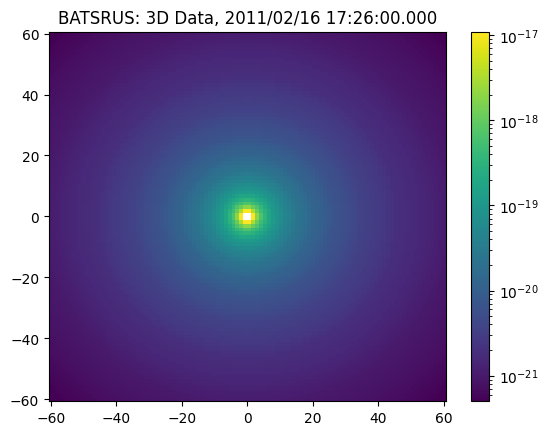

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from starwinds_readplt.dataset import Dataset

from batcamp import OctreeInterpolator

# Read the dataset
ds = Dataset.from_file("../example_data/3d__var_4_n00000000.plt")
print(ds)

# Create the octree and interpolator
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"])
print(interp)

# Create a Cartesian slice and interpolate density
X, Y = np.meshgrid(np.linspace(-60, 60, 100), np.linspace(-60, 60, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, rho, norm="log")
fig.colorbar(pcm, ax=ax)
ax.set_title(ds.title)
plt.show()


# 

# Fetch and resample some more intersting results
The results are cached with `pooch`, and may take some time to download on the first run.

In [7]:
import pooch
url="https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz"
known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136"
members = [
    "run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt",
    "run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt",
]

files = pooch.retrieve(url, 
                       known_hash=known_hash, 
                       progressbar=True,                       
                       processor=pooch.Untar(members=members)
)

print(files)

['/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt', '/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt']


## Plot solar corona (SC) file data
This file contains data with a spherical octree structure

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0044000'
Variables: 24
Shape:     (532480, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].
OctreeInterpolator(tree_coord=rpa, fields=1[Rho [g/cm^3]], n_points=532480, n_cells=524288, n_components=1)


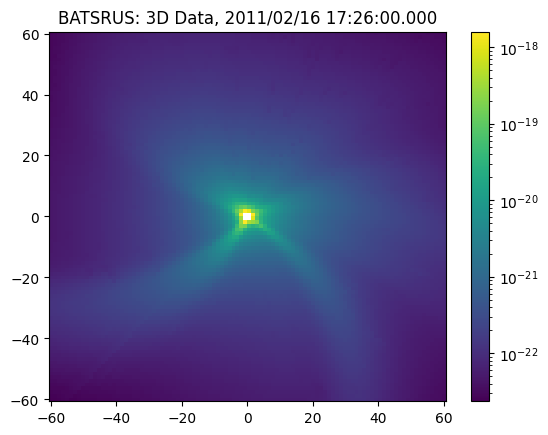

In [11]:
file = files[0]

# Read the dataset
ds = Dataset.from_file(file)
print(ds)

# SC file is spherical/rpa
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"])
print(interp)

# Cartesian slice
X, Y = np.meshgrid(np.linspace(-60, 60, 100), np.linspace(-60, 60, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)

pcm = plt.pcolormesh(X, Y, rho, norm="log")
plt.colorbar(pcm)
plt.title(ds.title)
plt.show()


## Plot the inner heliosphere (IH) file data
This file is has a cartesian octree structure

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0005000'
Variables: 24
Shape:     (4139545, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].
OctreeInterpolator(tree_coord=xyz, fields=1[Rho [g/cm^3]], n_points=4139545, n_cells=3835840, n_components=1)


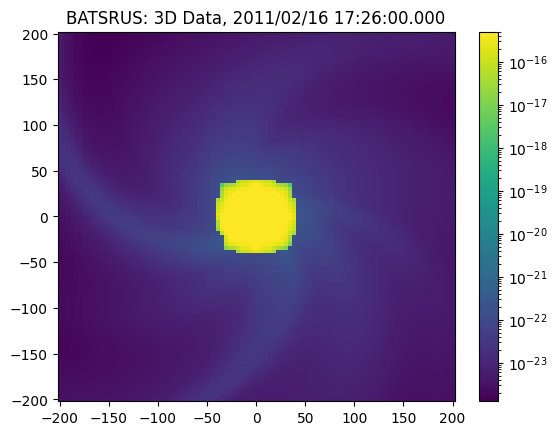

In [ ]:
file = files[1]

# Read the dataset
ds = Dataset.from_file(file)
print(ds)

interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"])
print(interp)

# Cartesian slice
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)

pcm = plt.pcolormesh(X, Y, rho, norm="log")
plt.colorbar(pcm)
plt.title(ds.title)
plt.show()
